# MAGA Hat Token-Score Analysis

This notebook visualizes Qwen3-VL token-level patch scores for generated maga_hat image pairs:
- Heatmaps for matched red-blue image pairs
- Distribution of all image token scores
- Red vs blue token-score distributions
- Pairwise red-blue score differences

In [1]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Default scenario for new pipeline outputs.
MODEL_FAMILY = "qwen3_vl"
DATASET = "maga_hat"
RIDGE_PREFIX = "combined_ideology"
PROBE_NAME = "headwise_linear"

# Legacy path support (kept for backward compatibility).
LEGACY_RESULTS_DIR = Path("results/qwen3-vl-8b-instruct/maga_hat")
LEGACY_PT_PATH = LEGACY_RESULTS_DIR / "news_images_patch_scores.pt"
LEGACY_CSV_PATH = LEGACY_RESULTS_DIR / "news_images_patch_stats.csv"
LEGACY_ALL_TOKENS_PATH = LEGACY_RESULTS_DIR / "news_images_all_tokens.pt"

NEW_RESULTS_DIR = Path(f"results/token_scoring/{MODEL_FAMILY}/{DATASET}")
NEW_PT_PATH = NEW_RESULTS_DIR / f"prompt_image_token_scores_{RIDGE_PREFIX}_{PROBE_NAME}.pt"
NEW_CSV_PATH = NEW_RESULTS_DIR / f"prompt_token_stats_{RIDGE_PREFIX}_{PROBE_NAME}.csv"
NEW_ALL_TOKENS_PATH = NEW_RESULTS_DIR / f"prompt_all_token_scores_{RIDGE_PREFIX}_{PROBE_NAME}.pt"

IMAGE_BASE = Path("data/gemini_tie_pairs/maga_hat_balanced/images")

if NEW_PT_PATH.exists() and NEW_CSV_PATH.exists():
    PT_PATH = NEW_PT_PATH
    CSV_PATH = NEW_CSV_PATH
    ALL_TOKENS_PATH = NEW_ALL_TOKENS_PATH
    RESULT_MODE = "new"
elif LEGACY_PT_PATH.exists() and LEGACY_CSV_PATH.exists():
    PT_PATH = LEGACY_PT_PATH
    CSV_PATH = LEGACY_CSV_PATH
    ALL_TOKENS_PATH = LEGACY_ALL_TOKENS_PATH
    RESULT_MODE = "legacy"
else:
    raise FileNotFoundError(
        "Could not find either new or legacy maga_hat result files.\n"
        f"Tried new: {NEW_PT_PATH} and {NEW_CSV_PATH}\n"
        f"Tried legacy: {LEGACY_PT_PATH} and {LEGACY_CSV_PATH}"
    )

payload = torch.load(PT_PATH, map_location="cpu")
stats_df = pd.read_csv(CSV_PATH)

# Handle naming differences between legacy and new payload formats.
image_names = payload.get("record_names") or payload.get("image_names")
if image_names is None:
    image_names = [Path(p).name for p in payload["image_paths"]]

grid_hw = payload["grid_hw"].numpy()
offsets = payload["offsets"].numpy()
scores = payload["scores"].numpy().astype(np.float32)

# Prefer payload-provided paths when they exist; otherwise map to IMAGE_BASE.
image_paths = []
for p in payload["image_paths"]:
    pth = Path(str(p))
    if pth.exists():
        image_paths.append(str(pth))
    else:
        image_paths.append(str(IMAGE_BASE / pth.name))

def image_score_vector(i: int) -> np.ndarray:
    start = int(offsets[i])
    end = int(offsets[i + 1])
    return scores[start:end]

def image_score_grid(i: int) -> np.ndarray:
    h, w = grid_hw[i]
    vec = image_score_vector(i)
    return vec.reshape(int(h), int(w))

def image_group(name: str) -> str:
    lower = str(name).lower()
    if "_red" in lower:
        return "red"
    if "_blue" in lower:
        return "blue"
    return "other"

def pair_key(name: str) -> str:
    stem = Path(str(name)).stem
    stem = re.sub(r"_(democrat|republican)_(red|blue)$", "", stem, flags=re.IGNORECASE)
    stem = re.sub(r"_(red|blue)$", "", stem, flags=re.IGNORECASE)
    return stem

meta = pd.DataFrame({
    "image_name": image_names,
    "image_path": image_paths,
    "grid_h": grid_hw[:, 0],
    "grid_w": grid_hw[:, 1],
})
meta["group"] = meta["image_name"].map(image_group)
meta["pair_key"] = meta["image_name"].map(pair_key)
meta["num_tokens"] = offsets[1:] - offsets[:-1]
meta["mean_score"] = [float(image_score_vector(i).mean()) for i in range(len(meta))]

print(f"Loaded mode: {RESULT_MODE}")
print(f"PT file    : {PT_PATH}")
print(f"CSV file   : {CSV_PATH}")
print(f"Loaded {len(meta)} images and {len(scores)} patch-token scores")
print(meta["group"].value_counts(dropna=False).to_string())
meta.head()

Loaded mode: new
PT file    : results/token_scoring/qwen3_vl/maga_hat/prompt_image_token_scores_combined_ideology_headwise_linear.pt
CSV file   : results/token_scoring/qwen3_vl/maga_hat/prompt_token_stats_combined_ideology_headwise_linear.csv
Loaded 200 images and 70000 patch-token scores
group
blue    100
red     100


,image_name,image_path,grid_h,grid_w,group,pair_key,num_tokens,mean_score
0,20260501_013351_magahat_001_with_hat_democrat_...,results/token_scoring/qwen3_vl/maga_hat/_resiz...,14,25,blue,20260501_013351_magahat_001_with_hat,350,-0.020355
1,20260501_013351_magahat_001_with_hat_republica...,results/token_scoring/qwen3_vl/maga_hat/_resiz...,14,25,red,20260501_013351_magahat_001_with_hat,350,0.271681
2,20260501_013351_magahat_002_with_hat_democrat_...,results/token_scoring/qwen3_vl/maga_hat/_resiz...,14,25,blue,20260501_013351_magahat_002_with_hat,350,0.065672
3,20260501_013351_magahat_002_with_hat_republica...,results/token_scoring/qwen3_vl/maga_hat/_resiz...,14,25,red,20260501_013351_magahat_002_with_hat,350,0.329733
4,20260501_013351_magahat_003_with_hat_democrat_...,results/token_scoring/qwen3_vl/maga_hat/_resiz...,14,25,blue,20260501_013351_magahat_003_with_hat,350,0.242807


Computed hat masks for 100 pairs
Mean hat-area token fraction per pair: 0.022 (min=0.006, max=0.163)


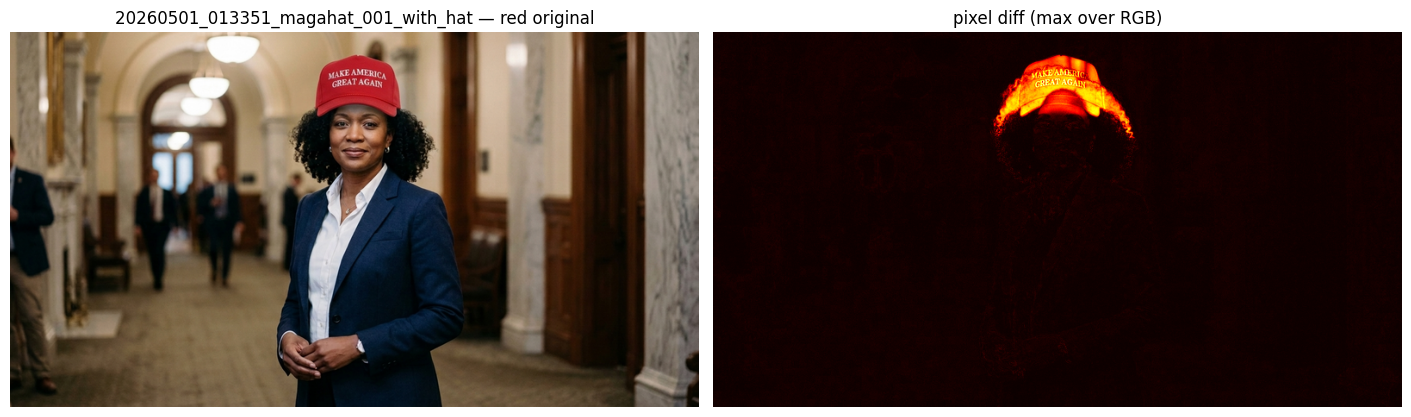

In [2]:
# Detect hat area using pixel difference between red and blue images of each pair.
# For each matched pair, compute the per-pixel absolute difference (max across RGB),
# threshold to get a binary hat mask, then map it down to the token patch grid.
from PIL import Image

# Rebuild valid pairs list (red/blue matched by pair_key)
pair_counts = meta.groupby(["pair_key", "group"]).size().unstack(fill_value=0)
valid_pairs = pair_counts[(pair_counts.get("red", 0) > 0) & (pair_counts.get("blue", 0) > 0)].index.tolist()

# Build pair map: pair_key -> (red_idx, blue_idx, red_path, blue_path)
pair_map = {}
for key in valid_pairs:
    red_row = meta[(meta["pair_key"] == key) & (meta["group"] == "red")]
    blue_row = meta[(meta["pair_key"] == key) & (meta["group"] == "blue")]
    if len(red_row) == 0 or len(blue_row) == 0:
        continue
    red_idx = int(red_row.index[0])
    blue_idx = int(blue_row.index[0])
    pair_map[key] = (red_idx, blue_idx,
                     str(red_row.iloc[0]["image_path"]),
                     str(blue_row.iloc[0]["image_path"]))

# Compute pixel-difference hat mask for each pair.
# Store token-grid-level binary masks.
DIFF_THRESHOLD = 30  # pixel intensity difference threshold (0-255 scale)

hat_mask_by_idx = {}  # image_idx -> binary mask at token grid resolution (H_grid, W_grid)
hat_mask_pixel_by_pair = {}  # pair_key -> binary mask at pixel resolution + bbox

for key, (red_idx, blue_idx, red_path, blue_path) in pair_map.items():
    red_img = np.array(Image.open(red_path).convert("RGB")).astype(np.float32)
    blue_img = np.array(Image.open(blue_path).convert("RGB")).astype(np.float32)
    h_img, w_img = red_img.shape[:2]

    # Per-pixel max difference across RGB channels — only the hat changes
    pixel_diff = np.abs(red_img - blue_img).max(axis=2)
    pixel_mask = (pixel_diff > DIFF_THRESHOLD).astype(np.float32)

    # Map pixel mask to token grid resolution by averaging within each patch
    red_grid = image_score_grid(red_idx)
    h_grid, w_grid = red_grid.shape

    token_mask = np.zeros((h_grid, w_grid), dtype=np.float32)
    for i in range(h_grid):
        i0 = int(i * h_img / h_grid)
        i1 = int((i + 1) * h_img / h_grid)
        for j in range(w_grid):
            j0 = int(j * w_img / w_grid)
            j1 = int((j + 1) * w_img / w_grid)
            token_mask[i, j] = pixel_mask[i0:i1, j0:j1].mean()

    # Binarize: token is in hat area if > 50% of its pixels differ
    token_mask_bin = (token_mask > 0.5).astype(np.float32)

    hat_mask_by_idx[red_idx] = token_mask_bin
    hat_mask_by_idx[blue_idx] = token_mask_bin
    hat_mask_pixel_by_pair[key] = {"pixel_diff": pixel_diff, "pixel_mask": pixel_mask}

print(f"Computed hat masks for {len(hat_mask_pixel_by_pair)} pairs")
hat_fractions = [hat_mask_by_idx[r].mean() for r, _, _, _ in pair_map.values()]
print(f"Mean hat-area token fraction per pair: {np.mean(hat_fractions):.3f}"
      f" (min={np.min(hat_fractions):.3f}, max={np.max(hat_fractions):.3f})")

# Quick diagnostic: show one pair's pixel difference and resulting token mask
demo_key = valid_pairs[0]
demo_red_idx = pair_map[demo_key][0]
demo_pdiff = hat_mask_pixel_by_pair[demo_key]["pixel_diff"]
demo_tmask = hat_mask_by_idx[demo_red_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
axes[0].imshow(Image.open(pair_map[demo_key][2]))
axes[0].set_title(f"{demo_key} — red original"); axes[0].axis("off")
axes[1].imshow(demo_pdiff, cmap="hot")
axes[1].set_title(f"pixel diff (max over RGB)"); axes[1].axis("off")

plt.show()


Red  hat-only mean: n=100,   mean=0.6350, std=0.1858
Blue hat-only mean: n=100,  mean=-0.3181, std=0.4057
Hat-only delta (red-blue): 0.9530


,image_name,group,mean_score,hat_mean_score,hat_n_tokens
0,20260501_013351_magahat_001_with_hat_democrat_...,blue,-0.020355,-0.343514,7
1,20260501_013351_magahat_001_with_hat_republica...,red,0.271681,0.731168,7
2,20260501_013351_magahat_002_with_hat_democrat_...,blue,0.065672,-0.616415,6
3,20260501_013351_magahat_002_with_hat_republica...,red,0.329733,0.675865,6
4,20260501_013351_magahat_003_with_hat_democrat_...,blue,0.242807,-0.384725,6
5,20260501_013351_magahat_003_with_hat_republica...,red,0.611610,0.518263,6
6,20260501_013351_magahat_004_with_hat_democrat_...,blue,0.109181,-0.700370,6
7,20260501_013351_magahat_004_with_hat_republica...,red,0.354411,0.491856,6
8,20260501_013351_magahat_005_with_hat_democrat_...,blue,0.229040,0.045050,10
9,20260501_013351_magahat_005_with_hat_republica...,red,0.472242,0.689381,10


/scratch/local/jobs/49684146/ipykernel_1561860/1795227656.py:159: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


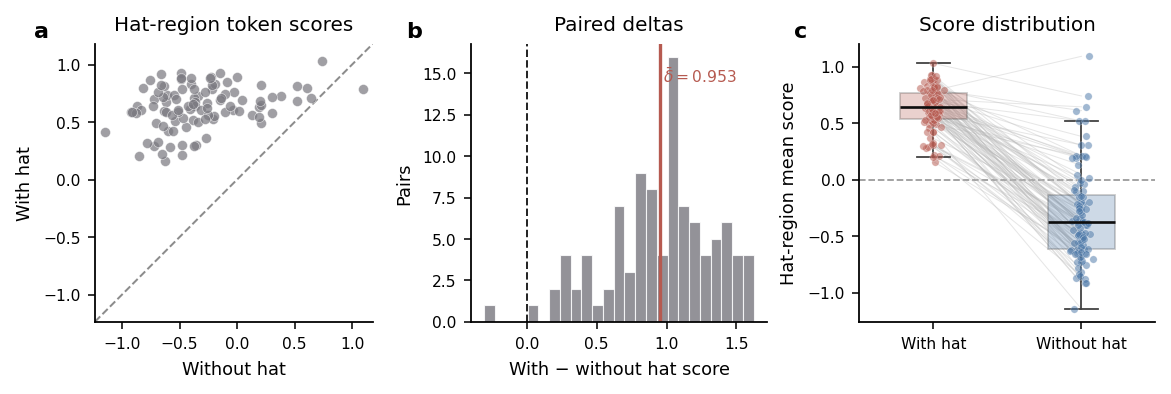

In [3]:
# Compute per-image hat-area mean token score (only tokens inside the hat mask).
meta["hat_mean_score"] = np.nan
meta["hat_n_tokens"] = 0
for i in range(len(meta)):
    if i in hat_mask_by_idx and hat_mask_by_idx[i].sum() > 0:
        grid = image_score_grid(i)
        mask = hat_mask_by_idx[i]
        h = min(grid.shape[0], mask.shape[0])
        w = min(grid.shape[1], mask.shape[1])
        hat_vals = grid[:h, :w][mask[:h, :w] > 0]
        meta.loc[i, "hat_mean_score"] = float(hat_vals.mean())
        meta.loc[i, "hat_n_tokens"] = int(mask.sum())

red_hat = meta.loc[meta["group"] == "red", "hat_mean_score"].dropna()
blue_hat = meta.loc[meta["group"] == "blue", "hat_mean_score"].dropna()
print(f"Red  hat-only mean: n={len(red_hat)},   mean={red_hat.mean():.4f}, std={red_hat.std():.4f}")
print(f"Blue hat-only mean: n={len(blue_hat)},  mean={blue_hat.mean():.4f}, std={blue_hat.std():.4f}")
print(f"Hat-only delta (red-blue): {red_hat.mean() - blue_hat.mean():.4f}")
display(meta[["image_name", "group", "mean_score", "hat_mean_score", "hat_n_tokens"]].head(10))

# ── Pair-wise hat-only delta analysis ──
paired_hat = (
    meta[meta["group"].isin(["red", "blue"])][["pair_key", "group", "hat_mean_score"]]
    .dropna()
    .pivot_table(index="pair_key", columns="group", values="hat_mean_score", aggfunc="first")
    .dropna()
)
paired_hat["delta_red_minus_blue"] = paired_hat["red"] - paired_hat["blue"]

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# ── Nature-style plotting defaults ──
mpl.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

delta = paired_hat["delta_red_minus_blue"].to_numpy()
mean_delta = delta.mean()
median_delta = np.median(delta)
share_pos = (delta > 0).mean()

fig, axes = plt.subplots(
    1, 3,
    figsize=(7.2, 2.35),
    constrained_layout=True
)

# Shared styling
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    ax.tick_params(direction="out")

# Muted, publication-friendly color palette
col_red = "#B65A50"       # muted terracotta
col_blue = "#4C78A8"      # muted steel blue
col_delta = "#7B7A81"     # muted purple
col_grey = "0.72"
col_dark = "0.15"

# ── Panel A: paired scatter ──
ax = axes[0]

ax.scatter(
    paired_hat["blue"],
    paired_hat["red"],
    s=20,
    alpha=0.72,
    color=col_delta,
    edgecolor="white",
    linewidth=0.25,
)

mn = float(min(paired_hat["blue"].min(), paired_hat["red"].min()))
mx = float(max(paired_hat["blue"].max(), paired_hat["red"].max()))
pad = 0.04 * (mx - mn) if mx > mn else 0.01

ax.plot(
    [mn - pad, mx + pad],
    [mn - pad, mx + pad],
    linestyle="--",
    color="0.55",
    linewidth=0.9,
    zorder=0,
)

ax.set_xlim(mn - pad, mx + pad)
ax.set_ylim(mn - pad, mx + pad)
ax.set_aspect("equal", adjustable="box")
ax.set_title("Hat-region token scores")
ax.set_xlabel("Without hat")
ax.set_ylabel("With hat")


# ── Panel B: delta histogram ──
ax = axes[1]
bins = np.histogram_bin_edges(delta, bins=25)

ax.hist(
    delta,
    bins=bins,
    color=col_delta,
    alpha=0.82,
    edgecolor="white",
    linewidth=0.5,
)

ax.axvline(
    0,
    color=col_dark,
    linestyle="--",
    linewidth=0.9,
)

ax.axvline(
    mean_delta,
    color=col_red if mean_delta >= 0 else col_blue,
    linewidth=1.5,
)

ymax = ax.get_ylim()[1]
ax.text(
    mean_delta * 1.02,
    ymax * 0.92,
    f"$\\bar{{\\delta}} = {mean_delta:.3f}$",
    ha="left" if mean_delta >= 0 else "right",
    va="top",
    fontsize=7,
    color=col_red if mean_delta >= 0 else col_blue,
)

ax.set_title("Paired deltas")
ax.set_xlabel("With − without hat score")
ax.set_ylabel("Pairs")


# ── Panel C: paired distribution ──
ax = axes[2]

box = ax.boxplot(
    [
        paired_hat["red"].to_numpy(),
        paired_hat["blue"].to_numpy(),
    ],
    labels=["With hat", "Without hat"],
    widths=0.45,
    showfliers=False,
    patch_artist=True,
    medianprops=dict(color="0.05", linewidth=1.2),
    boxprops=dict(edgecolor="0.25", linewidth=0.8),
    whiskerprops=dict(color="0.25", linewidth=0.8),
    capprops=dict(color="0.25", linewidth=0.8),
)

# Color boxes softly
for patch, color in zip(box["boxes"], [col_red, col_blue]):
    patch.set_facecolor(color)
    patch.set_alpha(0.28)

# Add individual paired points with slight jitter
rng = np.random.default_rng(7)
x_red = rng.normal(1, 0.035, size=len(paired_hat))
x_blue = rng.normal(2, 0.035, size=len(paired_hat))

# Faint paired lines first, behind points
for yr, yb in zip(paired_hat["red"], paired_hat["blue"]):
    ax.plot(
        [1, 2],
        [yr, yb],
        color=col_grey,
        linewidth=0.45,
        alpha=0.35,
        zorder=1,
    )

ax.scatter(
    x_red,
    paired_hat["red"],
    s=11,
    color=col_red,
    alpha=0.52,
    edgecolor="white",
    linewidth=0.2,
    zorder=2,
)

ax.scatter(
    x_blue,
    paired_hat["blue"],
    s=11,
    color=col_blue,
    alpha=0.52,
    edgecolor="white",
    linewidth=0.2,
    zorder=2,
)

ax.axhline(
    0,
    color="0.6",
    linestyle="--",
    linewidth=0.8,
    zorder=0,
)

ax.set_title("Score distribution")
ax.set_ylabel("Hat-region mean score")


# Panel labels
for label, ax in zip(["a", "b", "c"], axes):
    ax.text(
        -0.22,
        1.08,
        label,
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        va="top",
        ha="left",
    )

plt.show()


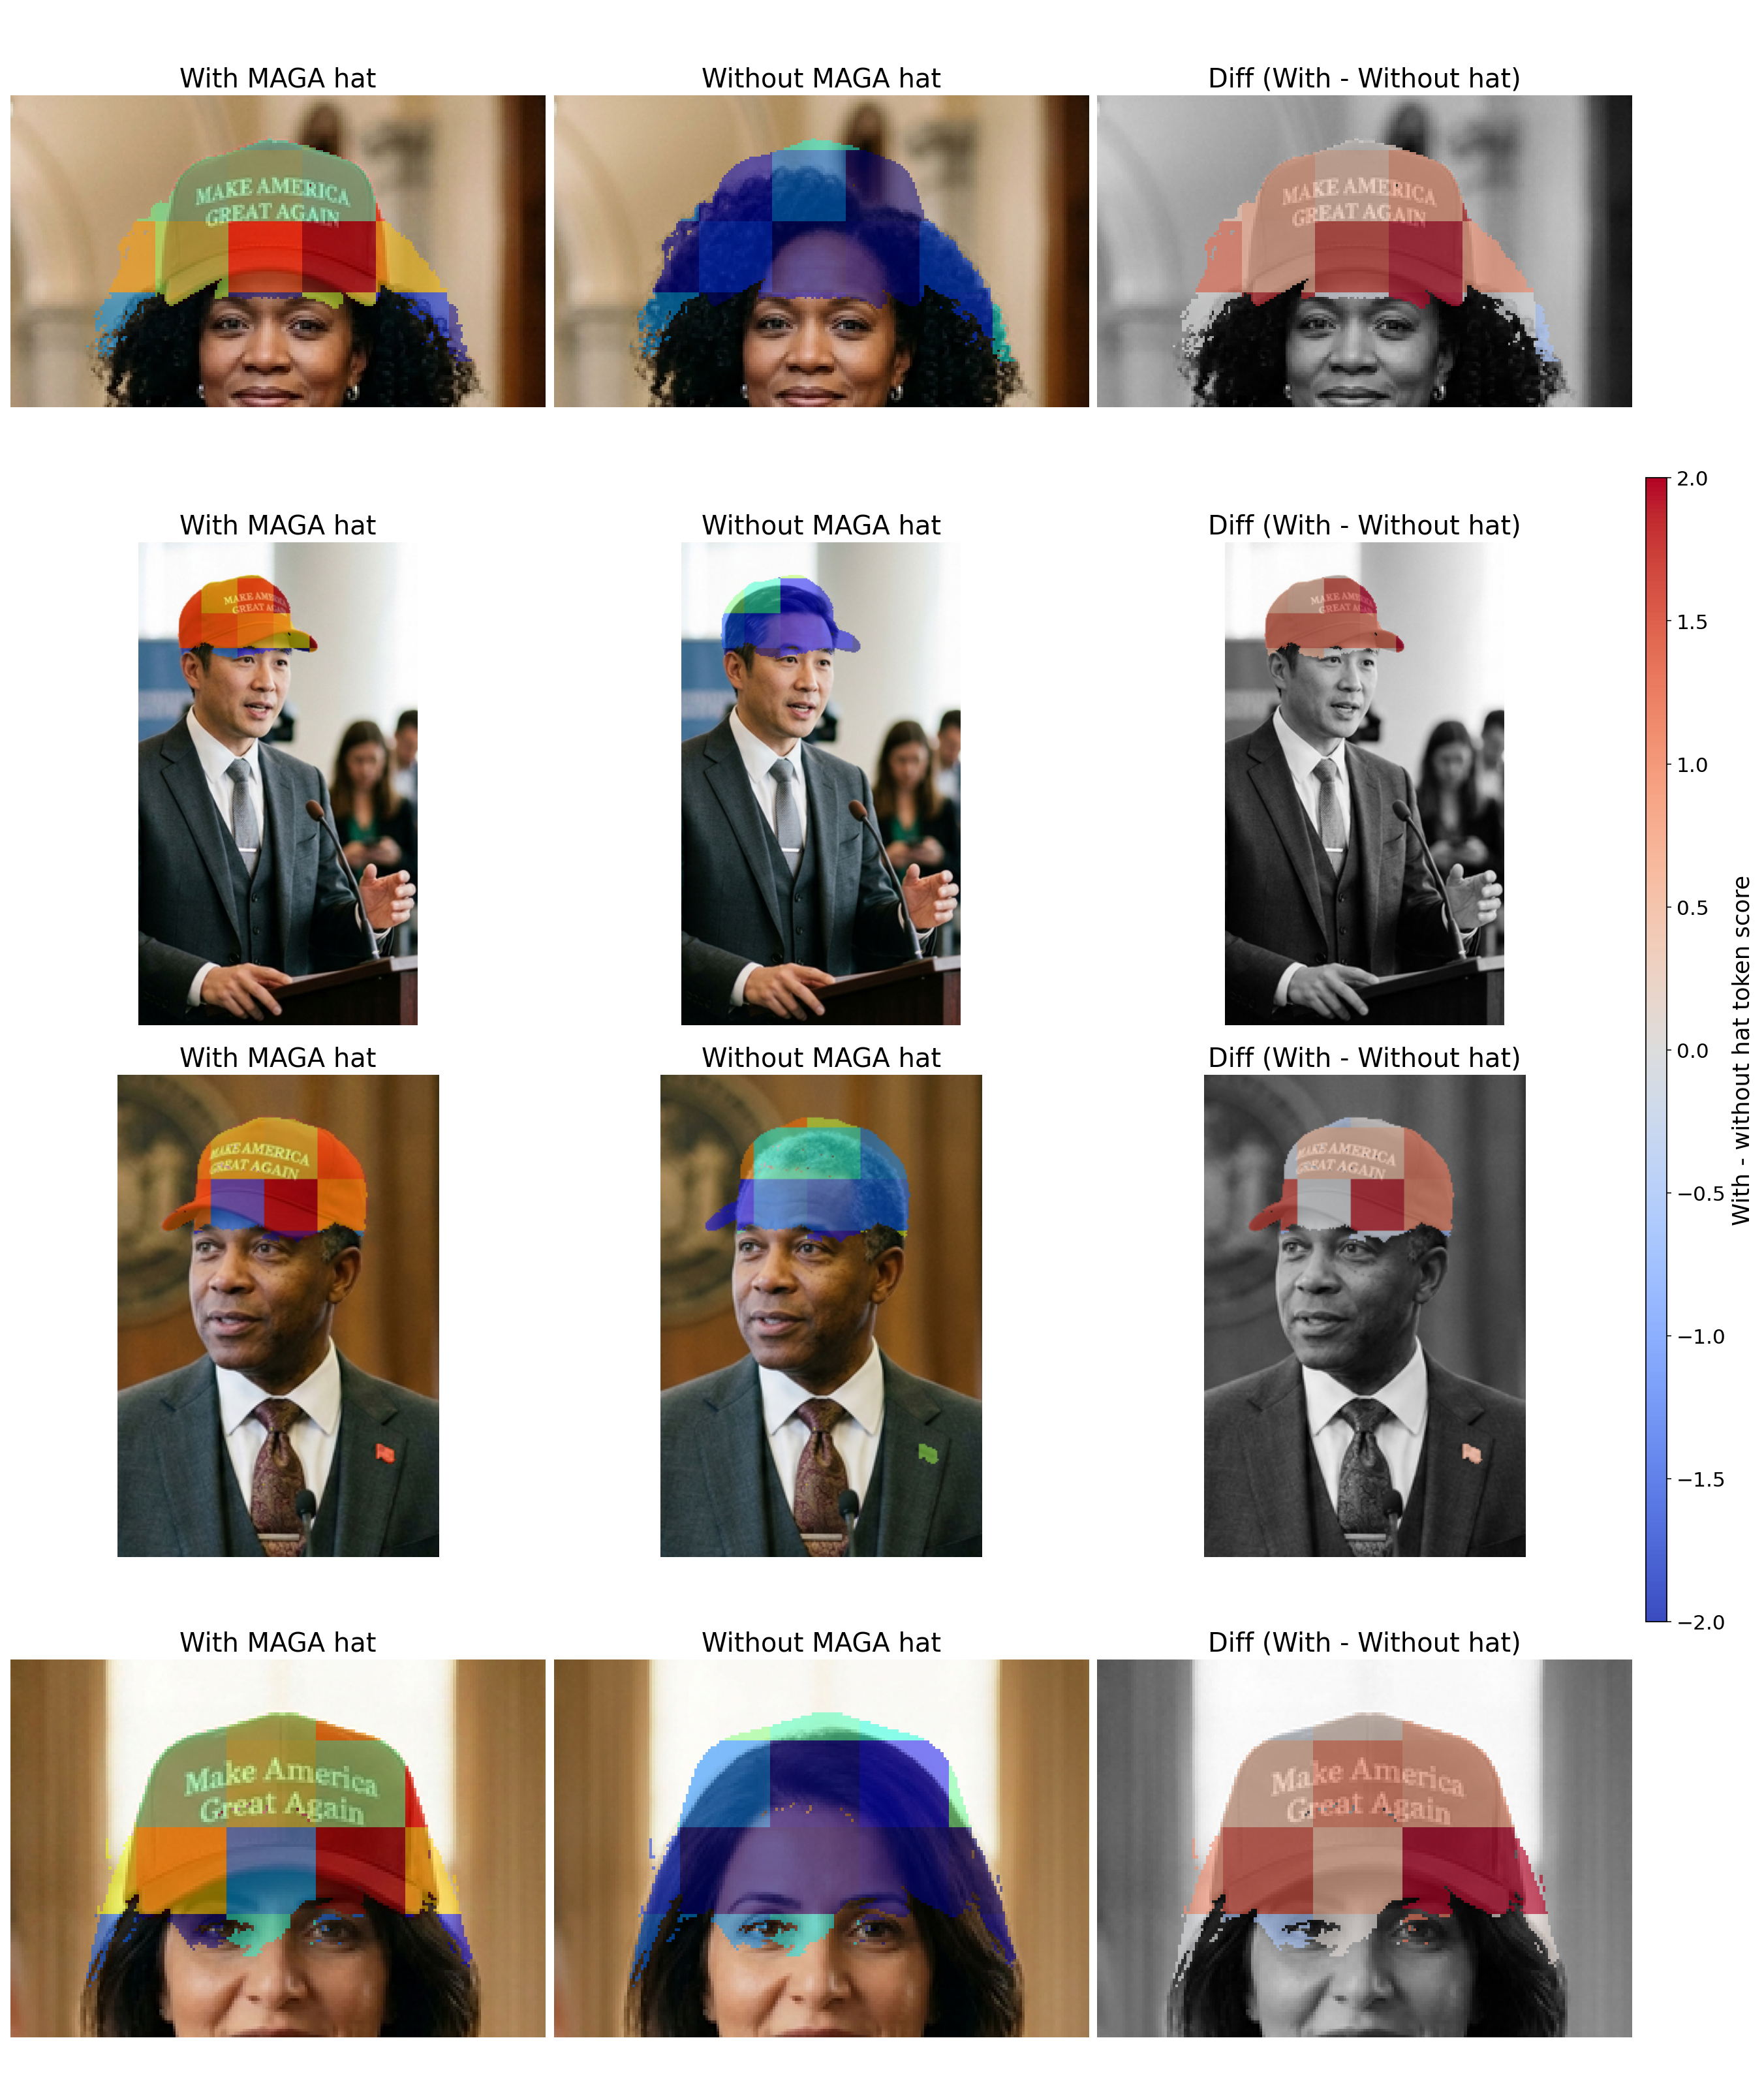

In [4]:
from PIL import Image
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 20,
})


if "hat_mask_pixel_by_pair" not in locals():
    raise RuntimeError("Run hat mask detection cell first.")

def hat_bbox(pixel_mask, pad_ratio=0.2):
    """Return (y0, y1, x0, x1) crop box from pixel mask with padding."""
    ys, xs = np.where(pixel_mask > 0)
    if len(ys) == 0:
        return 0, pixel_mask.shape[0], 0, pixel_mask.shape[1]
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    h_box = y1 - y0
    w_box = x1 - x0
    pad_y = int(h_box * pad_ratio)
    pad_x = int(w_box * pad_ratio)
    return (max(0, y0 - pad_y), min(pixel_mask.shape[0], y1 + pad_y),
            max(0, x0 - pad_x), min(pixel_mask.shape[1], x1 + pad_x))


def crop_overlay(img_pil, score_grid, pixel_mask, bbox,
                 on_hat=True, alpha=0.55, cmap_name="jet", vmin=None, vmax=None):
    """Crop image to bbox, overlay heatmap only on hat (on_hat=True) or not (on_hat=False).

    Returns (cropped_overlay_rgb, vmin, vmax).
    """
    img = np.asarray(img_pil.convert("RGB")).astype(np.float32) / 255.0
    h_img, w_img = img.shape[:2]
    h_grid, w_grid = score_grid.shape

    y0, y1, x0, x1 = bbox
    h_c, w_c = y1 - y0, x1 - x0

    img_crop = img[y0:y1, x0:x1]
    mask_hat = pixel_mask[y0:y1, x0:x1] > 0.5

    py = ((np.arange(h_c, dtype=np.float32) + y0) * h_grid / h_img).astype(int)
    px = ((np.arange(w_c, dtype=np.float32) + x0) * w_grid / w_img).astype(int)
    py = np.clip(py, 0, h_grid - 1)
    px = np.clip(px, 0, w_grid - 1)
    hm = score_grid[py[:, None], px[None, :]].astype(np.float32)

    if vmin is None:
        if mask_hat.any():
            vmin, vmax = float(np.nanmin(hm[mask_hat])), float(np.nanmax(hm[mask_hat]))
        else:
            vmin, vmax = float(hm.min()), float(hm.max())
    denom = (vmax - vmin) if (vmax - vmin) > 1e-8 else 1.0
    hm01 = np.clip((hm - vmin) / denom, 0.0, 1.0)

    cm = plt.get_cmap(cmap_name)
    hm_rgb = cm(hm01)[..., :3]

    out = img_crop.copy()
    target = mask_hat if on_hat else (~mask_hat)
    out[target] = (1 - alpha) * img_crop[target] + alpha * hm_rgb[target]
    return np.clip(out, 0.0, 1.0), vmin, vmax


n_show = min(4, len(valid_pairs))
show_pairs = valid_pairs[:n_show]

# Set explicit static global limits for the diff configurations
FIXED_VMIN = -2
FIXED_VMAX = 2

fig = plt.figure(figsize=(16, 5.0 * n_show), constrained_layout=True)
# Create a grid with 4 columns: 3 equal slots for images, 1 narrow buffer slot for the colorbar
gs = gridspec.GridSpec(n_show, 4, figure=fig, width_ratios=[1, 1, 1, 0.06])

# Build the axes array to match existing row loop logic
axes = np.empty((n_show, 3), dtype=object)
for r in range(n_show):
    for c in range(3):
        axes[r, c] = fig.add_subplot(gs[r, c])

for row, key in enumerate(show_pairs):
    red_idx, blue_idx = pair_map[key][0], pair_map[key][1]
    red_grid = image_score_grid(red_idx)
    blue_grid = image_score_grid(blue_idx)
    pixel_mask = hat_mask_pixel_by_pair[key]["pixel_mask"]

    h = min(red_grid.shape[0], blue_grid.shape[0])
    w = min(red_grid.shape[1], blue_grid.shape[1])
    red_common = red_grid[:h, :w]
    blue_common = blue_grid[:h, :w]
    diff = red_common - blue_common

    red_img_pil = Image.open(meta.loc[red_idx, "image_path"]).convert("RGB")
    blue_img_pil = Image.open(meta.loc[blue_idx, "image_path"]).convert("RGB")
    gray_img_pil = Image.open(meta.loc[red_idx, "image_path"]).convert("L").convert("RGB")

    # Compute shared crop box from hat mask once, use for all three columns
    bbox = hat_bbox(pixel_mask)

    # ── Column 1: hat overlay on red image ──
    hat_overlay, vmin, vmax = crop_overlay(red_img_pil, red_common, pixel_mask, bbox,
                                            on_hat=True, alpha=0.5, cmap_name="jet")
    axes[row, 0].imshow(hat_overlay)
    axes[row, 0].set_title("With MAGA hat")
    axes[row, 0].axis("off")

    # ── Column 2: hat overlay on blue image ──
    non_hat_overlay, _, _ = crop_overlay(blue_img_pil, blue_common, pixel_mask, bbox,
                                          on_hat=True, alpha=0.5, cmap_name="jet",
                                          vmin=vmin, vmax=vmax)
    axes[row, 1].imshow(non_hat_overlay)
    axes[row, 1].set_title("Without MAGA hat")
    axes[row, 1].axis("off")

    # ── Column 3: diff (red − blue) overlay on grey image using FIXED global scales ──
    diff_overlay, _, _ = crop_overlay(gray_img_pil, diff, pixel_mask, bbox,
                                      on_hat=True, alpha=0.65, cmap_name="coolwarm",
                                      vmin=FIXED_VMIN, vmax=FIXED_VMAX)
    axes[row, 2].imshow(diff_overlay)
    axes[row, 2].set_title("Diff (With - Without hat)")
    axes[row, 2].axis("off")

# ── Dedicated Colorbar Axis Configuration ──
# Anchor an axis wrapper matching the 4th column slot spanning all rows
cax_container = fig.add_subplot(gs[:, 3])
cax_container.axis("off") # Hide layout container borders

# Create an inset axis precisely centered inside the slot to scale down height
cax = inset_axes(cax_container,
                 width="65%",       # Thickness inside the slot width
                 height="55%",      # Shorter height adjustment (adjust percentage to taste)
                 loc="center")

sm_diff = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=FIXED_VMIN, vmax=FIXED_VMAX))
sm_diff.set_array([])

cbar = fig.colorbar(sm_diff, cax=cax)
cbar.set_label("With - without hat token score")

plt.show()

Red  last-token score: n=100, mean=0.1684, std=0.0556
Blue last-token score: n=100, mean=0.0784, std=0.0526
Delta (red-blue): 0.0900


/scratch/local/jobs/49684146/ipykernel_1561860/3850904270.py:152: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


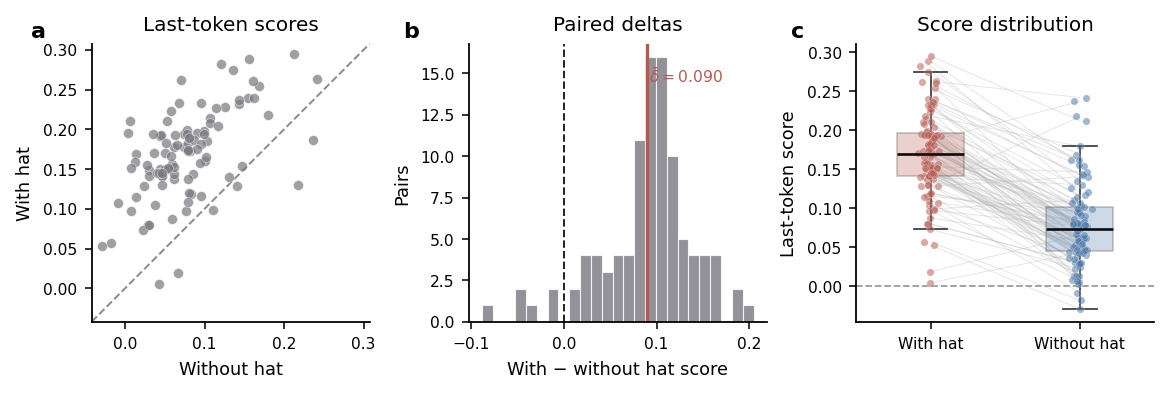

In [5]:
# ── Load all_token_scores and extract last-token scores ──
all_tokens = torch.load(ALL_TOKENS_PATH, map_location="cpu")
all_token_scores = all_tokens["all_token_scores"]

# Extract last-token score for each image
last_token_scores = np.array([float(s[-1].item()) if isinstance(s, torch.Tensor) else float(s[-1]) for s in all_token_scores])
meta["last_token_score"] = last_token_scores

# Print summary stats by group
red_last = meta.loc[meta["group"] == "red", "last_token_score"]
blue_last = meta.loc[meta["group"] == "blue", "last_token_score"]
print(f"Red  last-token score: n={len(red_last)}, mean={red_last.mean():.4f}, std={red_last.std():.4f}")
print(f"Blue last-token score: n={len(blue_last)}, mean={blue_last.mean():.4f}, std={blue_last.std():.4f}")
print(f"Delta (red-blue): {red_last.mean() - blue_last.mean():.4f}")

# ── Pair-wise last-token score analysis ──
paired_last = (
    meta[meta["group"].isin(["red", "blue"])][["pair_key", "group", "last_token_score"]]
    .dropna()
    .pivot_table(index="pair_key", columns="group", values="last_token_score", aggfunc="first")
    .dropna()
)
paired_last["delta_red_minus_blue"] = paired_last["red"] - paired_last["blue"]

# ── Nature-style plotting defaults ──
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

mpl.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

delta = paired_last["delta_red_minus_blue"].to_numpy()
mean_delta = delta.mean()
median_delta = np.median(delta)
share_pos = (delta > 0).mean()

fig, axes = plt.subplots(
    1, 3,
    figsize=(7.2, 2.35),
    constrained_layout=True
)

# Shared styling
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    ax.tick_params(direction="out")

# Muted, publication-friendly color palette
col_red = "#B65A50"
col_blue = "#4C78A8"
col_delta = "#7B7A81"
col_grey = "0.72"
col_dark = "0.15"

# ── Panel A: paired scatter ──
ax = axes[0]

ax.scatter(
    paired_last["blue"],
    paired_last["red"],
    s=20,
    alpha=0.72,
    color=col_delta,
    edgecolor="white",
    linewidth=0.25,
)

mn = float(min(paired_last["blue"].min(), paired_last["red"].min()))
mx = float(max(paired_last["blue"].max(), paired_last["red"].max()))
pad = 0.04 * (mx - mn) if mx > mn else 0.01

ax.plot(
    [mn - pad, mx + pad],
    [mn - pad, mx + pad],
    linestyle="--",
    color="0.55",
    linewidth=0.9,
    zorder=0,
)

ax.set_xlim(mn - pad, mx + pad)
ax.set_ylim(mn - pad, mx + pad)
ax.set_aspect("equal", adjustable="box")
ax.set_title("Last-token scores")
ax.set_xlabel("Without hat")
ax.set_ylabel("With hat")

# ── Panel B: delta histogram ──
ax = axes[1]
bins = np.histogram_bin_edges(delta, bins=25)

ax.hist(
    delta,
    bins=bins,
    color=col_delta,
    alpha=0.82,
    edgecolor="white",
    linewidth=0.5,
)

ax.axvline(
    0,
    color=col_dark,
    linestyle="--",
    linewidth=0.9,
)

ax.axvline(
    mean_delta,
    color=col_red if mean_delta >= 0 else col_blue,
    linewidth=1.5,
)

ymax = ax.get_ylim()[1]
ax.text(
    mean_delta * 1.02,
    ymax * 0.92,
    f"$\\bar{{\\delta}} = {mean_delta:.3f}$",
    ha="left" if mean_delta >= 0 else "right",
    va="top",
    fontsize=7,
    color=col_red if mean_delta >= 0 else col_blue,
)

ax.set_title("Paired deltas")
ax.set_xlabel("With − without hat score")
ax.set_ylabel("Pairs")

# ── Panel C: paired distribution ──
ax = axes[2]

box = ax.boxplot(
    [
        paired_last["red"].to_numpy(),
        paired_last["blue"].to_numpy(),
    ],
    labels=["With hat", "Without hat"],
    widths=0.45,
    showfliers=False,
    patch_artist=True,
    medianprops=dict(color="0.05", linewidth=1.2),
    boxprops=dict(edgecolor="0.25", linewidth=0.8),
    whiskerprops=dict(color="0.25", linewidth=0.8),
    capprops=dict(color="0.25", linewidth=0.8),
)

for patch, color in zip(box["boxes"], [col_red, col_blue]):
    patch.set_facecolor(color)
    patch.set_alpha(0.28)

rng = np.random.default_rng(7)
x_red = rng.normal(1, 0.035, size=len(paired_last))
x_blue = rng.normal(2, 0.035, size=len(paired_last))

for yr, yb in zip(paired_last["red"], paired_last["blue"]):
    ax.plot(
        [1, 2],
        [yr, yb],
        color=col_grey,
        linewidth=0.45,
        alpha=0.35,
        zorder=1,
    )

ax.scatter(
    x_red,
    paired_last["red"],
    s=11,
    color=col_red,
    alpha=0.52,
    edgecolor="white",
    linewidth=0.2,
    zorder=2,
)

ax.scatter(
    x_blue,
    paired_last["blue"],
    s=11,
    color=col_blue,
    alpha=0.52,
    edgecolor="white",
    linewidth=0.2,
    zorder=2,
)

ax.axhline(
    0,
    color="0.6",
    linestyle="--",
    linewidth=0.8,
    zorder=0,
)

ax.set_title("Score distribution")
ax.set_ylabel("Last-token score")

# Panel labels
for label, ax in zip(["a", "b", "c"], axes):
    ax.text(
        -0.22,
        1.08,
        label,
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        va="top",
        ha="left",
    )

plt.show()
